# 🥋 AI Karate Sensei — Model Tournament
## Notebook 1: Bi-LSTM — The Efficiency King
**Bracket 1:** Tests Feature Set A (XYZV, 132 features) vs Feature Set B (Angles, 14 features)

| | Feature Set A: Coords (132) | Feature Set B: Angles (14) |
|---|---|---|
| **Bi-LSTM** | ✅ Run here | ✅ Run here |

**Goal:** Determine if 14 smart biomechanical angles can match or beat 132 raw XYZV coordinates.

## 📦 0. Install & Import

In [1]:
# Run once if not installed:
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Bidirectional, LSTM, Dense,
                                      Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print(f'TensorFlow: {tf.__version__}')
print(f'GPU Available: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.18.0
GPU Available: []


## ⚙️ 1. Configuration

In [2]:
# ─── PATHS ───────────────────────────────────────────────────────────────────
BASE_DIR      = Path(r"D:\CS-Senior26'\GR\Karate_phase")
ANGLES_CSV    = BASE_DIR / 'karate_angles.csv'    # Feature Set B (14 angles)
COORDS_CSV    = BASE_DIR / 'karate_coords.csv'    # Feature Set A (132 XYZV)
RESULTS_DIR   = BASE_DIR / 'Model_Build' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
METRIC_LOG    = BASE_DIR / 'Model_Build' / 'tournament_metrics.csv'

# ─── HYPERPARAMETERS ─────────────────────────────────────────────────────────
SEQUENCE_LEN  = 30          # Fixed 30 frames per clip
EPOCHS        = 80
BATCH_SIZE    = 16
DROPOUT_RATE  = 0.4
LSTM_UNITS    = [128, 64]   # Two Bi-LSTM layers
TEST_SIZE     = 0.2
RANDOM_SEED   = 42

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('✅ Config loaded')

✅ Config loaded


## 📂 2. Data Loader

In [3]:
def load_sequence_data(csv_path, feature_cols):
    """
    Loads a CSV where each clip has SEQUENCE_LEN rows (frames).
    Returns X (n_clips, 30, n_features), y (n_clips,), le, class_names.
    """
    df = pd.read_csv(csv_path)
    print(f"Loaded: {csv_path.name} | Rows: {len(df)} | Columns: {len(df.columns)}")
    print(f"Classes found: {df['label'].unique()}")
    print(f"Clips: {df['clip_id'].nunique()}")

    le = LabelEncoder()
    df['label_enc'] = le.fit_transform(df['label'])
    class_names = list(le.classes_)

    X, y = [], []
    for clip_id, group in df.groupby('clip_id'):
        group_sorted = group.sort_values('frame')
        if len(group_sorted) != SEQUENCE_LEN:
            idx = np.linspace(0, len(group_sorted)-1, SEQUENCE_LEN).astype(int)
            group_sorted = group_sorted.iloc[idx]
        X.append(group_sorted[feature_cols].values.astype(np.float32))
        y.append(group_sorted['label_enc'].iloc[0])

    X = np.array(X)   # (N, 30, features)
    y = np.array(y)
    print(f"✅ X shape: {X.shape} | y shape: {y.shape}")
    return X, y, le, class_names

# Feature columns
ANGLE_COLS = [f'angle_{i:02d}' for i in range(14)]
COORD_COLS = [f'{dim}{i}' for i in range(33) for dim in ['x','y','z','v']]

print('Data loader ready ✅')

Data loader ready ✅


## 🏗️ 3. Model Architecture — Bi-LSTM

In [4]:
def build_bilstm(input_shape, n_classes):
    """
    Bidirectional LSTM:
      Input → BiLSTM(128) → BN → Dropout
           → BiLSTM(64)  → BN → Dropout
           → Dense(64)   → Dense(n_classes, softmax)
    """
    model = Sequential([
        Bidirectional(LSTM(LSTM_UNITS[0], return_sequences=True),
                      input_shape=input_shape),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        Bidirectional(LSTM(LSTM_UNITS[1], return_sequences=False)),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),

        Dense(64, activation='relu'),
        Dropout(DROPOUT_RATE / 2),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print('Model builder ready ✅')

Model builder ready ✅


## 🏋️ 4. Training & Evaluation Helper

In [5]:
def log_metrics(metrics_dict):
    df_new = pd.DataFrame([metrics_dict])
    if METRIC_LOG.exists():
        df_new.to_csv(METRIC_LOG, mode='a', header=False, index=False)
    else:
        df_new.to_csv(METRIC_LOG, index=False)
    print(f'✅ Metrics appended to {METRIC_LOG.name}')


def train_and_evaluate(X, y, class_names, feature_label, model_name='Bi-LSTM'):
    n_classes = len(class_names)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED)

    y_train_cat = to_categorical(y_train, n_classes)
    y_test_cat  = to_categorical(y_test,  n_classes)

    model = build_bilstm((SEQUENCE_LEN, X.shape[2]), n_classes)
    model.summary()

    callbacks = [
        EarlyStopping(patience=12, restore_best_weights=True, monitor='val_accuracy'),
        ReduceLROnPlateau(factor=0.5, patience=6, min_lr=1e-5)
    ]

    t0 = time.time()
    history = model.fit(
        X_train, y_train_cat,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - t0

    t_inf = time.time()
    y_pred_prob = model.predict(X_test, batch_size=BATCH_SIZE)
    inference_latency_ms = ((time.time() - t_inf) / len(X_test)) * 1000

    y_pred = np.argmax(y_pred_prob, axis=1)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')

    model_path = RESULTS_DIR / f'{model_name}_{feature_label}.keras'
    model.save(model_path)
    model_size_mb = os.path.getsize(model_path) / 1e6

    sep = '='*60
    print(f'\n{sep}')
    print(f'  {model_name} + {feature_label} RESULTS')
    print(f'{sep}')
    print(f'  Accuracy:          {acc:.4f}  ({acc*100:.1f}%)')
    print(f'  F1-Score:          {f1:.4f}')
    print(f'  Inference Latency: {inference_latency_ms:.2f} ms/clip')
    print(f'  Model Size:        {model_size_mb:.2f} MB')
    print(f'  Training Time:     {train_time:.0f}s')
    print(f'{sep}\n')
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{model_name} + {feature_label} — Confusion Matrix')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_{feature_label}_cm.png', dpi=150)
    plt.show()

    # Learning curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Val')
    ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')
    ax2.plot(history.history['loss'],         label='Train')
    ax2.plot(history.history['val_loss'],     label='Val')
    ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')
    plt.suptitle(f'{model_name} + {feature_label}', fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_{feature_label}_learning_curve.png', dpi=150)
    plt.show()

    metrics = {
        'timestamp':     datetime.now().strftime('%Y-%m-%d %H:%M'),
        'model':         model_name,
        'feature_set':   feature_label,
        'n_features':    X.shape[2],
        'n_clips':       len(X),
        'accuracy':      round(acc, 4),
        'f1_weighted':   round(f1, 4),
        'inference_ms':  round(inference_latency_ms, 2),
        'model_size_mb': round(model_size_mb, 2),
        'train_time_s':  round(train_time, 1),
        'epochs_ran':    len(history.history['accuracy'])
    }
    log_metrics(metrics)
    return metrics

print('Training pipeline ready ✅')

Training pipeline ready ✅


## 🚀 5A. Run — Feature Set B: Angles (14 features)

🔩 Loading ANGLES data...
Loaded: karate_angles.csv | Rows: 11880 | Columns: 17
Classes found: ['GedanBarai' 'MaeGeri' 'Gyakudzuki']
Clips: 396
✅ X shape: (396, 30, 14) | y shape: (396,)


d:\CS-Senior26'\GR\cvEnv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       146,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,771 (1.22 MB)

 Trainable params: 320,003 (1.22 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.5634 - loss: 1.1901 - val_accuracy: 0.4792 - val_loss: 1.0109 - learning_rate: 0.0010
Epoch 2/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6455 - loss: 0.7805 - val_accuracy: 0.4792 - val_loss: 0.9731 - learning_rate: 0.0010
Epoch 3/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7873 - loss: 0.5498 - val_accuracy: 0.5000 - val_loss: 0.9435 - learning_rate: 0.0010
Epoch 4/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8396 - loss: 0.3950 - val_accuracy: 0.5625 - val_loss: 0.8791 - learning_rate: 0.0010
Epoch 5/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8769 - loss: 0.2961 - val_accuracy: 0.7083 - val_loss: 0.8583 - learning_rate: 0.0010
Epoch 6/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8843 - loss: 0.2901 - val_accuracy: 0.7083 - val_loss: 0.9200 - learning_rate: 0.0010
Epoch 7/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9104 - loss: 0.2313 - val_ac

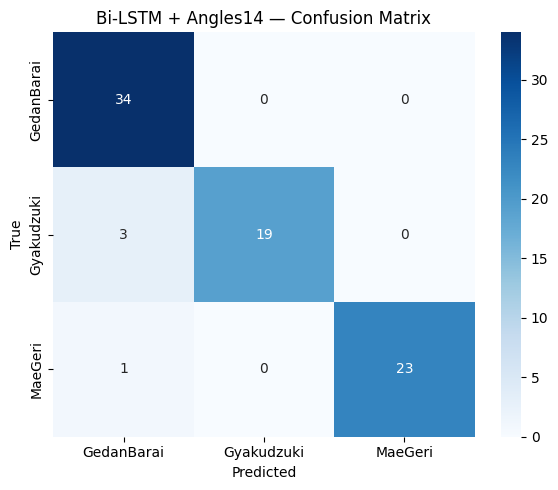

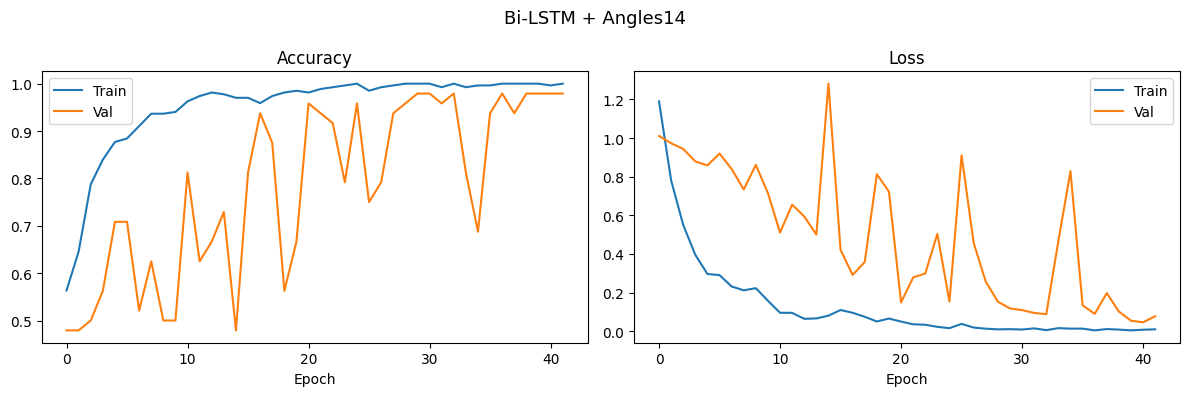

✅ Metrics appended to tournament_metrics.csv


In [6]:
print('🔩 Loading ANGLES data...')
X_ang, y_ang, le_ang, classes_ang = load_sequence_data(ANGLES_CSV, ANGLE_COLS)
metrics_ang = train_and_evaluate(X_ang, y_ang, classes_ang,
                                  feature_label='Angles14',
                                  model_name='Bi-LSTM')

## 🚀 5B. Run — Feature Set A: XYZV Coords (132 features)

🔩 Loading COORDS data...
Loaded: karate_coords.csv | Rows: 11880 | Columns: 135
Classes found: ['GedanBarai' 'MaeGeri' 'Gyakudzuki']
Clips: 396
✅ X shape: (396, 30, 132) | y shape: (396,)


d:\CS-Senior26'\GR\cvEnv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 30, 256)        │       267,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 441,603 (1.68 MB)

 Trainable params: 440,835 (1.68 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.4291 - loss: 1.4208 - val_accuracy: 0.4583 - val_loss: 1.0511 - learning_rate: 0.0010
Epoch 2/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5373 - loss: 1.0238 - val_accuracy: 0.4792 - val_loss: 1.0477 - learning_rate: 0.0010
Epoch 3/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6269 - loss: 0.9098 - val_accuracy: 0.5208 - val_loss: 1.0618 - learning_rate: 0.0010
Epoch 4/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5746 - loss: 0.9506 - val_accuracy: 0.5000 - val_loss: 1.0166 - learning_rate: 0.0010
Epoch 5/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6642 - loss: 0.7979 - val_accuracy: 0.5000 - val_loss: 0.9580 - learning_rate: 0.0010
Epoch 6/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7388 - loss: 0.5883 - val_accuracy: 0.4792 - val_loss: 0.9023 - learning_rate: 0.0010
Epoch 7/80
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7799 - loss: 0.5221 - val_acc

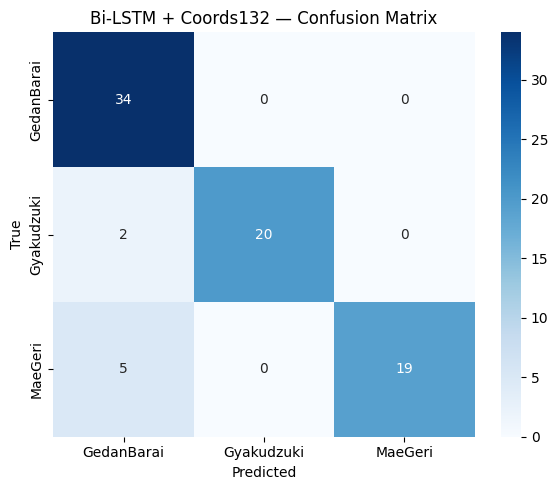

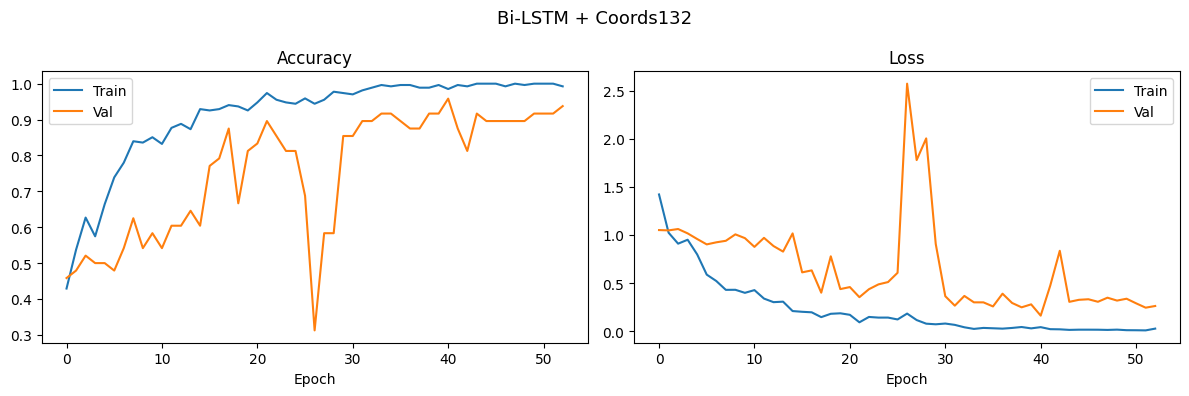

✅ Metrics appended to tournament_metrics.csv


In [7]:
print('🔩 Loading COORDS data...')
X_coord, y_coord, le_coord, classes_coord = load_sequence_data(COORDS_CSV, COORD_COLS)
metrics_coord = train_and_evaluate(X_coord, y_coord, classes_coord,
                                    feature_label='Coords132',
                                    model_name='Bi-LSTM')

## 📊 6. Bracket 1 Summary

In [8]:
bracket1 = pd.DataFrame([metrics_ang, metrics_coord])[[
    'model','feature_set','n_features','accuracy','f1_weighted','inference_ms','model_size_mb'
]]
print('\n🏆 BRACKET 1 RESULTS:')
display(bracket1.style
    .highlight_max(axis=0, subset=['accuracy','f1_weighted'])
    .highlight_min(axis=0, subset=['inference_ms','model_size_mb']))


🏆 BRACKET 1 RESULTS:


,model,feature_set,n_features,accuracy,f1_weighted,inference_ms,model_size_mb
0,Bi-LSTM,Angles14,14,0.950000,0.949900,7.380000,3.920000
1,Bi-LSTM,Coords132,132,0.912500,0.912400,6.150000,5.370000
